# Length-Stress Test — closed_book vs full_context, across genres

Truncated to 1k/2k/3k/6k/10k words, under **closed_book** and **full_context**.

| genre | corpus | format |
|---|---|---|
| `novel` | 6 books, own ladder | extractive |
| `wiki` | New York City (~15k words) | extractive |
| `news` | NewsQA (~50k words) | extractive |
| `caselaw` | CaseHOLD (~55k words) | multiple choice (5) |

`statute` retired (LLM-written questions, no ladder possible).

> `wiki` closed_book: 0.67/0.63/0.70 (rungs 1-3) vs 0.34 full set — front-loaded parametric knowledge.

`novel` truncates per-book then pools. Others truncate the single corpus. Scored only when `answerable` at that rung.

> `full_context` isn't reproducible at temp=0 (~3.5% row flips on rerun); effects under ±2pp on ~50 questions are noise.


In [ ]:
import hashlib
import os
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from itertools import combinations
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import matplotlib.pyplot as plt
import pandas as pd
import requests
from tqdm.auto import tqdm

from src.pipeline.chuncking import plain_text_to_paragraphs

project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env loaded: success ✅
NVIDIA_NIM_API_KEY: set ✅


/Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Build every genre's ladder, then flag answerability

`novel` reuses `01`'s per-book ladders; other genres truncated here directly (deterministic, no API).


In [2]:
VERSIONS = [1000, 2000, 3000, 6000, 10000, 20000, 30000, 50000]

# wiki is deliberately absent: its closed_book accuracy runs 0.63-0.70 on the
# short rungs (the model already knows the New York City article), so it
# measures contamination rather than context use. It stays in
# 03_qa_baseline_3conditions.ipynb as a contamination control.
GENRES = {
    "novel": {
        "questions_path": "data/sample/narrativeqa_length_stress.csv",
        "units_dir": Path("data/processed/narrativeqa_length_stress/docs"),
        "format": "extractive",
    },
    "wiki": {
        "questions_path": "data/sample/wiki_eval_questions.csv",
        "corpus_path": "data/processed/wiki_eval/wiki_eval_corpus.txt",
        "format": "extractive",
    },
    "news": {
        "questions_path": "data/sample/news_eval_questions.csv",
        "corpus_path": "data/processed/news_eval/news_eval_corpus.txt",
        "format": "extractive",
    },
    "caselaw": {
        "questions_path": "data/sample/caselaw_eval_questions.csv",
        "corpus_path": "data/processed/caselaw_eval/caselaw_eval_corpus.txt",
        "format": "multiple_choice",
    },
}


def truncate_to_word_count(paragraphs: list, full_text: str, target_words: int) -> str:
    """Cut at the nearest paragraph boundary without exceeding target_words.
    Uses paragraphs[i+1].char_offset (the real position in the source) rather
    than char_offset + len(text), since plain_text_to_paragraphs normalizes
    internal whitespace and that drift would accumulate."""
    cumulative_words = 0
    cut_char_pos = 0
    for i, p in enumerate(paragraphs):
        p_words = len(p.text.split())
        if cumulative_words > 0 and cumulative_words + p_words > target_words:
            break
        cumulative_words += p_words
        next_offset = paragraphs[i + 1].char_offset if i + 1 < len(paragraphs) else len(full_text)
        cut_char_pos = next_offset
    return full_text[:cut_char_pos]


unit_texts: dict[tuple[str, str, int], str] = {}
unit_words: dict[tuple[str, str, int], int] = {}
genre_fingerprint: dict[str, str] = {}
frames = []

for genre, cfg in GENRES.items():
    raw_questions = Path(cfg["questions_path"]).read_bytes()
    qdf = pd.read_csv(cfg["questions_path"], encoding="utf-8-sig")
    corpus_bytes = b""

    if "units_dir" in cfg:  # novel — one ladder per book, already on disk from 01
        qdf["unit_id"] = qdf["doc_slug"]
        for unit_id in sorted(qdf["unit_id"].unique()):
            for v in VERSIONS:
                # A book shorter than a rung has no file for it (01 skips those).
                path = cfg["units_dir"] / unit_id / f"length_stress_v{v}.txt"
                if not path.exists():
                    continue
                text = path.read_text(encoding="utf-8")
                unit_texts[(genre, unit_id, v)] = text
                unit_words[(genre, unit_id, v)] = len(text.split())
            corpus_bytes += (cfg["units_dir"] / unit_id / "full.txt").read_bytes()
    else:  # single corpus — truncate here
        qdf["unit_id"] = genre
        full_text = Path(cfg["corpus_path"]).read_text(encoding="utf-8")
        corpus_bytes = full_text.encode("utf-8")
        paragraphs = plain_text_to_paragraphs(full_text)
        corpus_words = len(full_text.split())
        for v in VERSIONS:
            # Same rule as the per-book ladders: a rung longer than the corpus
            # would just be the whole corpus again, i.e. a silently duplicated
            # point on the curve. Skip it.
            if corpus_words < v:
                continue
            text = truncate_to_word_count(paragraphs, full_text, v)
            unit_texts[(genre, genre, v)] = text
            unit_words[(genre, genre, v)] = len(text.split())

    # Question ids are positional (news/caselaw both use 1..N), so rebuilding a
    # corpus reuses ids for entirely different questions. Fingerprinting the
    # inputs lets stale checkpoint rows be detected instead of silently kept.
    genre_fingerprint[genre] = hashlib.sha1(raw_questions + corpus_bytes).hexdigest()[:10]

    for v in VERSIONS:
        qdf[f"answerable_v{v}"] = [
            (genre, unit, v) in unit_words and pos <= unit_words[(genre, unit, v)]
            for unit, pos in zip(qdf["unit_id"], qdf["evidence_word_pos"])
        ]
    qdf["genre"] = genre
    qdf["question_uid"] = genre + "::" + qdf["question_id"].astype(str)
    frames.append(qdf)

questions_df = pd.concat(frames, ignore_index=True)

cohort_table = pd.DataFrame(
    {f"v{v // 1000}k": questions_df.groupby("genre")[f"answerable_v{v}"].sum() for v in VERSIONS}
).reindex(list(GENRES))
cohort_table["total"] = questions_df.groupby("genre").size().reindex(list(GENRES))
cohort_table.loc["POOLED"] = cohort_table.sum()
print("answerable questions per rung:")
print(cohort_table.to_string())
print("\nfingerprints:", genre_fingerprint)

answerable questions per rung:
         v1k  v2k  v3k  v6k  v10k  v20k  v30k  v50k  total
genre                                                     
novel     28   41   50   56    79    74    85    64    107
wiki       6   16   23   45    71     0     0     0    100
news      10   17   24   40    60   102   137   199    200
caselaw    4    7   11   22    36    73   109   183    200
POOLED    48   81  108  163   246   249   331   446    607

fingerprints: {'novel': '3b2df04cea', 'wiki': '4cdc2fd9e0', 'news': '1ac028ae6d', 'caselaw': '4818fe5b03'}


## 2. NIM chat API call (`call_chat`)

Rate-limited (30/min), backoff, usage tracking — same as `03`.


In [3]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    return getattr(_usage_local, "value", None)


class RateLimiter:
    """Sliding-window limiter on max calls per minute."""

    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0])
            time.sleep(max(sleep_for, 0.1))


_rate_limiter = RateLimiter(max_per_minute=30)


def call_chat(messages: list[dict], model: str, api_key: str, timeout: float = 120.0, max_retries: int = 3) -> str:
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": 0.0},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(3.0 * (attempt + 1))
                continue
            raise RuntimeError(f"NIM chat API call failed (retries exhausted): {e}") from e

        if response.status_code == 200:
            payload = response.json()
            _usage_local.value = payload.get("usage")
            return payload["choices"][0]["message"]["content"]
        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(3.0 * (attempt + 1))
            continue
        raise RuntimeError(f"NIM chat API failed ({response.status_code}): {response.text}")

    raise RuntimeError(f"NIM chat API call failed (retries exhausted): {last_error}")

## 3. Message builders + scoring (both answer formats)

`caselaw` scored as an option number; others by normalized substring match.


In [4]:
_NO_TOOLS_SENTENCE = (
    "Do not use web search or any external tool — answer using only the information "
    "given to you (or your own prior knowledge)."
)
_OPEN_ANSWER_INSTRUCTION = (
    "Answer with only the answer itself, as briefly as possible (a word or short phrase). "
    "No other explanation."
)
_MC_ANSWER_INSTRUCTION = "Answer with only the number (1-5) of the correct option. No other explanation."


def normalize_answer(text: str) -> str:
    return re.sub(r"[\s\.,!?'\"()\[\]{}]", "", text).lower()


def is_correct_extractive(prediction: str, reference: str) -> bool:
    norm_ref = normalize_answer(str(reference))
    return bool(norm_ref) and norm_ref in normalize_answer(prediction)


def parse_option_number(text: str) -> int | None:
    match = re.search(r"[1-5]", text)
    return int(match.group()) if match else None


def is_correct(genre: str, row: pd.Series, prediction: str | None) -> bool:
    if prediction is None:
        return False
    if GENRES[genre]["format"] == "multiple_choice":
        idx = parse_option_number(prediction)
        return idx is not None and (idx - 1) == row["correct_option_index"]
    return is_correct_extractive(prediction, row["answer"])


def _question_turn(genre: str, row: pd.Series) -> dict:
    if GENRES[genre]["format"] == "multiple_choice":
        options = "\n".join(f"{i + 1}) {row[f'option_{i}']}" for i in range(5))
        content = f"{_MC_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}\n{options}"
    else:
        content = f"{_OPEN_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}"
    return {"role": "user", "content": content}


def _system_turn() -> dict:
    return {"role": "system", "content": f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions."}


def build_messages_closedbook(genre: str, row: pd.Series) -> list[dict]:
    return [_system_turn(), _question_turn(genre, row)]


def build_messages_fullcontext(genre: str, row: pd.Series, context_text: str) -> list[dict]:
    context = {"role": "user", "content": f"Read the following text, then answer the question after it.\n\n{context_text}"}
    return [_system_turn(), context, _question_turn(genre, row)]

## 4. Experiment loop — genre x condition x rung

Parallel per question, checkpointed per `(genre, condition, version)`.


In [5]:
RESULTS_PATH = "results/length_stress_test.csv"
CONDITIONS = ["closed_book", "full_context"]
MAX_WORKERS = 8


def _ask(genre: str, condition: str, version: int | None, row: pd.Series) -> dict:
    try:
        if condition == "closed_book":
            messages = build_messages_closedbook(genre, row)
        else:
            messages = build_messages_fullcontext(genre, row, unit_texts[(genre, row["unit_id"], version)])

        t0 = time.time()
        reply = call_chat(messages, model=QA_MODEL, api_key=QA_API_KEY, timeout=180.0)
        elapsed = time.time() - t0
        prediction, error = reply.strip(), None
    except Exception as e:
        prediction, elapsed = None, None
        error = f"{type(e).__name__}: {e}"
        tqdm.write(f"  [{genre}/{condition}/{version}] {row['question_uid']} failed: {error}")

    return {
        "question_uid": row["question_uid"], "genre": genre, "unit_id": row["unit_id"],
        "genre_fp": genre_fingerprint[genre], "condition": condition, "length_version": version,
        "prediction": prediction, "correct": is_correct(genre, row, prediction),
        "elapsed_seconds": elapsed, "error": error,
    }


def _rungs(genre: str) -> list[int]:
    """Rungs where this genre actually has at least one answerable question."""
    return [v for v in VERSIONS if questions_df.loc[questions_df.genre == genre, f"answerable_v{v}"].any()]


if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY — skipping the experiment loop.")
    results_df = pd.DataFrame()
else:
    all_results, done = [], set()
    if Path(RESULTS_PATH).exists():
        prior = pd.read_csv(RESULTS_PATH)
        valid = set(zip(questions_df.question_uid, questions_df.genre.map(genre_fingerprint)))
        if "genre_fp" not in prior:
            prior["genre_fp"] = None
        keep = [(u, f) in valid for u, f in zip(prior.question_uid.astype(str), prior.genre_fp)]
        if (dropped := len(prior) - sum(keep)):
            print(f"dropping {dropped} stale rows (question_uid/fingerprint no longer current)")
            prior = prior[keep].reset_index(drop=True)
            prior.to_csv(RESULTS_PATH, index=False)  # repair on disk, not just in memory
        for (g, cond, ver), group in prior.groupby(["genre", "condition", "length_version"]):
            expected = questions_df.loc[questions_df.genre == g, f"answerable_v{int(ver)}"].sum()
            # A failed call is stored as correct=False, so a triple can hit its
            # expected count entirely out of failures and look "done".
            if len(group) >= expected and group["error"].isna().all():
                done.add((g, cond, int(ver)))
        all_results = prior.to_dict("records")

    for genre in GENRES:
        rungs = _rungs(genre)

        # closed_book never sees the document, so its prompt is byte-identical at
        # every rung — §7 confirms the accuracy is too (spread 0.0000). Ask once
        # per question and replicate to each rung it is scored at; asking per rung
        # would double this notebook's API cost for no information.
        if any((genre, "closed_book", v) not in done for v in rungs):
            subset = questions_df[
                (questions_df.genre == genre)
                & questions_df[[f"answerable_v{v}" for v in rungs]].any(axis=1)
            ]
            print(f"running: {genre}/closed_book ({len(subset)} questions, asked once each)")
            answers = {}
            with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
                futures = [executor.submit(_ask, genre, "closed_book", None, row) for _, row in subset.iterrows()]
                for future in tqdm(as_completed(futures), total=len(futures), desc=f"{genre}/closed_book"):
                    outcome = future.result()
                    answers[outcome["question_uid"]] = outcome

            all_results = [r for r in all_results
                           if not (r["genre"] == genre and r["condition"] == "closed_book")]
            for _, row in subset.iterrows():
                base = answers[row["question_uid"]]
                for v in rungs:
                    if row[f"answerable_v{v}"]:
                        all_results.append({**base, "length_version": v})
            pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False)

        for version in rungs:
            if (genre, "full_context", version) in done:
                continue
            subset = questions_df[(questions_df.genre == genre) & questions_df[f"answerable_v{version}"]]
            before = len(all_results)
            all_results = [r for r in all_results if not (
                r["genre"] == genre and r["condition"] == "full_context" and r["length_version"] == version)]
            if (removed := before - len(all_results)):
                print(f"  replacing {removed} existing rows for {genre}/full_context/{version}")
            print(f"running: {genre}/full_context/{version} ({len(subset)} questions)")

            with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
                futures = [executor.submit(_ask, genre, "full_context", version, row) for _, row in subset.iterrows()]
                for future in tqdm(as_completed(futures), total=len(futures), desc=f"{genre}/fc/{version}"):
                    all_results.append(future.result())

            pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False)

    results_df = pd.DataFrame(all_results)
    print(f"\ntotal results: {len(results_df)}")

running: news/closed_book (199 questions, asked once each)


news/closed_book: 100%|██████████| 199/199 [06:08<00:00,  1.85s/it]


running: news/full_context/1000 (10 questions)


news/fc/1000: 100%|██████████| 10/10 [00:03<00:00,  2.86it/s]


running: news/full_context/2000 (17 questions)


...

running: caselaw/full_context/30000 (109 questions)


caselaw/fc/30000: 100%|██████████| 109/109 [04:02<00:00,  2.22s/it]


running: caselaw/full_context/50000 (183 questions)


caselaw/fc/50000: 100%|██████████| 183/183 [06:00<00:00,  1.97s/it]


total results: 3344


In [6]:
# An API failure is recorded as correct=False, which would blend "the call never
# returned" into "read it and got it wrong". Check before analysing.
if not results_df.empty:
    n_failed = results_df["error"].notna().sum()
    n_empty = results_df["prediction"].isna().sum()
    print(f"failed calls: {n_failed} | empty/missing predictions: {n_empty} | rows: {len(results_df)}")
    if n_failed:
        print(results_df.loc[results_df.error.notna(),
                             ["question_uid", "genre", "condition", "length_version", "error"]].head(10).to_string(index=False))

failed calls: 0 | empty/missing predictions: 0 | rows: 3344


## 5. Accuracy by genre x rung

Raw view — denominators grow with length, §6 controls for that.


In [7]:
if results_df.empty:
    print("No results to analyze.")
else:
    for condition in CONDITIONS:
        sub = results_df[results_df.condition == condition]
        acc = sub.pivot_table(index="genre", columns="length_version", values="correct", aggfunc="mean")
        acc = acc.reindex(list(GENRES))
        acc.loc["POOLED"] = [sub[sub.length_version == v]["correct"].mean() for v in VERSIONS]
        n = sub.pivot_table(index="genre", columns="length_version", values="correct", aggfunc="count").reindex(list(GENRES))
        n.loc["POOLED"] = [int((sub.length_version == v).sum()) for v in VERSIONS]
        print(f"\n=== {condition} — accuracy ===")
        print(acc.round(3).to_string())
        print(f"--- n ---")
        print(n.astype("Int64").to_string())


=== closed_book — accuracy ===
length_version  1000   2000   3000   6000   10000  20000  30000  50000
genre                                                                 
novel           0.107  0.073  0.060  0.054  0.038  0.041  0.035  0.047
wiki            0.667  0.625  0.696  0.444  0.338    NaN    NaN    NaN
news            0.000  0.000  0.000  0.000  0.017  0.029  0.044  0.040
caselaw         0.250  0.429  0.364  0.364  0.361  0.274  0.284  0.317
POOLED          0.167  0.198  0.213  0.190  0.167  0.104  0.121  0.155
--- n ---
length_version  1000   2000   3000   6000   10000  20000  30000  50000
genre                                                                 
novel              28     41     50     56     79     74     85     64
wiki                6     16     23     45     71   <NA>   <NA>   <NA>
news               10     17     24     40     60    102    137    199
caselaw             4      7     11     22     36     73    109    183
POOLED             48     81    108

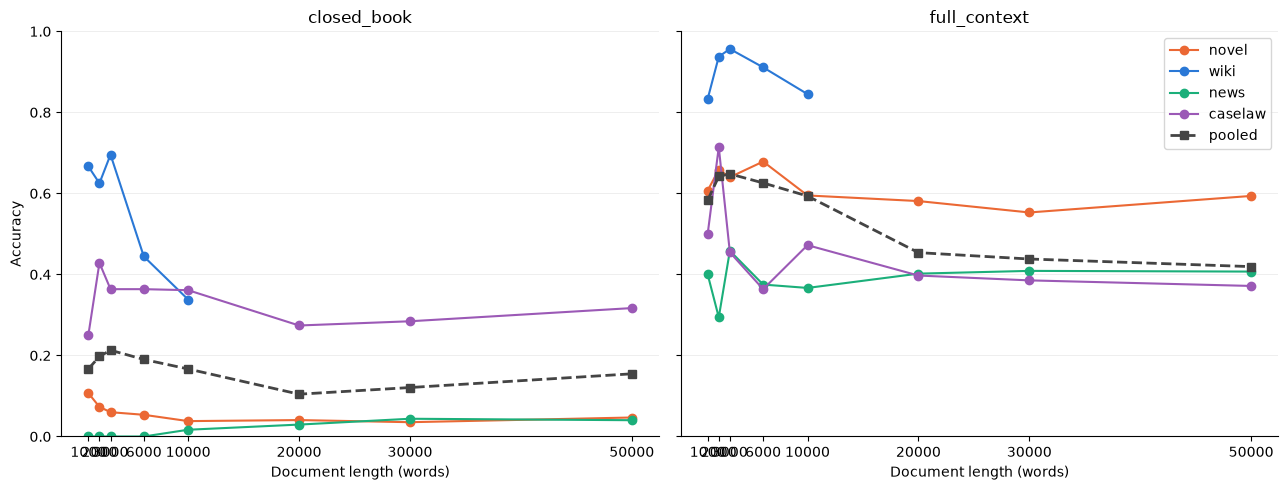

In [8]:
if not results_df.empty:
    GENRE_COLORS = {"novel": "#eb6834", "wiki": "#2a78d6", "news": "#1baf7a", "caselaw": "#9b59b6"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, condition in zip(axes, CONDITIONS):
        sub = results_df[results_df.condition == condition]
        for genre in GENRES:
            series = sub[sub.genre == genre].groupby("length_version")["correct"].mean().reindex(VERSIONS)
            ax.plot(VERSIONS, series, marker="o", label=genre, color=GENRE_COLORS[genre])
        pooled = sub.groupby("length_version")["correct"].mean().reindex(VERSIONS)
        ax.plot(VERSIONS, pooled, marker="s", linestyle="--", color="#444", linewidth=2, label="pooled")
        ax.set_title(condition)
        ax.set_xlabel("Document length (words)")
        ax.set_xticks(VERSIONS)
        ax.set_ylim(0, 1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linewidth=0.5, alpha=0.3)
        ax.set_axisbelow(True)
    axes[0].set_ylabel("Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 6. Fixed-cohort accuracy

Question set frozen at a base rung, so difficulty stays constant across rungs.


In [9]:
def cohort_uids(base_version: int, genre: str | None = None) -> set[str]:
    """Questions answerable at base_version *by definition* — from the question
    set, not from whatever happens to be in results_df. Deriving the cohort from
    results would let a partial run quietly change it."""
    mask = questions_df[f"answerable_v{base_version}"]
    if genre is not None:
        mask &= questions_df.genre == genre
    return set(questions_df.loc[mask, "question_uid"])


def fixed_cohort(base_version: int, condition: str = "full_context", genre: str | None = None) -> pd.DataFrame:
    uids = cohort_uids(base_version, genre)
    subset = results_df[
        results_df.question_uid.isin(uids)
        & (results_df.condition == condition)
        & (results_df.length_version >= base_version)
    ]
    return subset.groupby("length_version")["correct"].agg(["mean", "sum", "count"])


if not results_df.empty:
    for base in (1000, 2000):
        print(f"\n=== pooled fixed cohort, v{base} baseline (full_context) ===")
        print(fixed_cohort(base).round(4).to_string())
        per_genre = pd.DataFrame({g: fixed_cohort(base, genre=g)["mean"] for g in GENRES})
        print("--- same cohort split by genre ---")
        print(per_genre.round(3).to_string())


=== pooled fixed cohort, v1000 baseline (full_context) ===
                  mean  sum  count
length_version                    
1000            0.5833   28     48
2000            0.5625   27     48
3000            0.6042   29     48
6000            0.6667   32     48
10000           0.6250   30     48
20000           0.5758   19     33
30000           0.5152   17     33
50000           0.4483   13     29
--- same cohort split by genre ---
                novel   wiki  news  caselaw
length_version                             
1000            0.607  0.833   0.4     0.50
2000            0.607  0.833   0.3     0.50
3000            0.679  0.833   0.4     0.25
6000            0.821  0.833   0.3     0.25
10000           0.714  0.833   0.3     0.50
20000           0.737    NaN   0.3     0.50
30000           0.684    NaN   0.3     0.25
50000           0.533    NaN   0.4     0.25

=== pooled fixed cohort, v2000 baseline (full_context) ===
                  mean  sum  count
length_version      

## 7. Noise floor and paired transitions

closed_book's fixed-cohort accuracy is constant across rungs (sanity check); full_context isn't reproducible at temp=0.


In [10]:
if not results_df.empty:
    print("noise floor — closed_book on fixed cohorts (should be perfectly flat):")
    for base in (1000, 2000):
        flat = fixed_cohort(base, condition="closed_book")["mean"].round(4)
        print(f"  v{base}: {dict(flat)}  spread={flat.max() - flat.min():.4f}")

noise floor — closed_book on fixed cohorts (should be perfectly flat):
  v1000: {1000: np.float64(0.1667), 2000: np.float64(0.1667), 3000: np.float64(0.1667), 6000: np.float64(0.1667), 10000: np.float64(0.1667), 20000: np.float64(0.1212), 30000: np.float64(0.1212), 50000: np.float64(0.1379)}  spread=0.0455
  v2000: {2000: np.float64(0.1975), 3000: np.float64(0.2099), 6000: np.float64(0.1852), 10000: np.float64(0.1975), 20000: np.float64(0.1132), 30000: np.float64(0.1132), 50000: np.float64(0.1224)}  spread=0.0967


In [11]:
def paired_transitions(base_version: int, condition: str = "full_context", genre: str | None = None) -> pd.DataFrame:
    """McNemar contingency between every pair of rungs, on a fixed cohort."""
    uids = cohort_uids(base_version, genre)
    matrix = (
        results_df[
            results_df.question_uid.isin(uids)
            & (results_df.condition == condition)
            & (results_df.length_version >= base_version)
        ]
        .pivot_table(index="question_uid", columns="length_version", values="correct")
        .dropna()
    )
    rows = []
    for a, b in combinations(sorted(matrix.columns), 2):
        lost = int(((matrix[a] == 1) & (matrix[b] == 0)).sum())
        gained = int(((matrix[a] == 0) & (matrix[b] == 1)).sum())
        rows.append({"from": a, "to": b, "n": len(matrix),
                     "correct_to_wrong": lost, "wrong_to_correct": gained, "net": gained - lost})
    return pd.DataFrame(rows)


if not results_df.empty:
    for base in (1000, 2000):
        print(f"\npooled full_context paired transitions — v{base} cohort:")
        print(paired_transitions(base).to_string(index=False))


pooled full_context paired transitions — v1000 cohort:
 from    to  n  correct_to_wrong  wrong_to_correct  net
 1000  2000 29                 3                 2   -1
 1000  3000 29                 2                 3    1
 1000  6000 29                 2                 5    3
 1000 10000 29                 2                 4    2
 1000 20000 29                 2                 5    3
 1000 30000 29                 4                 5    1
 1000 50000 29                 4                 5    1
 2000  3000 29                 1                 3    2
 2000  6000 29                 1                 5    4
 2000 10000 29                 1                 4    3
 2000 20000 29                 2                 6    4
 2000 30000 29                 2                 4    2
 2000 50000 29                 2                 4    2
 3000  6000 29                 1                 3    2
 3000 10000 29                 4                 5    1
 3000 20000 29                 3                

In [12]:
if not results_df.empty:
    print("v1000 cohort, adjacent-rung net change by genre (full_context):")
    rows = []
    for genre in GENRES:
        t = paired_transitions(1000, genre=genre)
        adjacent = t[[VERSIONS.index(b) - VERSIONS.index(a) == 1 for a, b in zip(t["from"], t["to"])]]
        rows.append(pd.Series(adjacent.set_index(adjacent["from"].astype(str) + "->" + adjacent["to"].astype(str))["net"], name=genre))
    print(pd.DataFrame(rows).to_string())

v1000 cohort, adjacent-rung net change by genre (full_context):
         1000->2000  2000->3000  3000->6000  6000->10000  10000->20000  20000->30000  30000->50000
novel           0.0         2.0         3.0         -2.0           1.0          -1.0          -1.0
wiki            0.0         0.0         0.0          0.0           NaN           NaN           NaN
news           -1.0         1.0        -1.0          0.0           0.0           0.0           1.0
caselaw         0.0        -1.0         0.0          1.0           0.0          -1.0           0.0


## Interpretation notes

4 genres, 607 questions, 3,344 rows, 0 failed calls. Ladder 1k-50k words (`wiki` stops at 10k).

### Accuracy does not degrade with length

| transition | correct→wrong | wrong→correct | net |
|---|---|---|---|
| v10k → v20k | 14 | 14 | +0 |
| v10k → v30k | 15 | 11 | −4 |
| **v10k → v50k** | **19** | **21** | **+2** |
| v30k → v50k | 8 | 14 | +6 |

143 questions, 5x context, net +2 (per-genre: novel +6, news −2, caselaw −2 — noise). v3000→v10000 net +1 (n=134).

**Length is not the binding constraint anywhere between 1,000 and 50,000 words.**

### What is binding: context goes underused

Context gain (full_context − closed_book):

| genre | 1k | 10k | 50k |
|---|---|---|---|
| novel | 0.500 | 0.557 | 0.547 |
| news | 0.400 | 0.350 | 0.367 |
| caselaw | 0.250 | 0.111 | 0.055 |
| wiki | 0.167 | 0.507 | — |

`news`: closed_book ~0, full_context never clears 0.41 — ~60% miss rate, constant regardless of length.

### Per-genre notes

- `caselaw`: context gain falls 0.250→0.055 as corpus grows (harder to locate the right excerpt among more).
- `wiki`: closed_book front-loaded (0.67/0.63/0.70 → 0.34 full), least clean measurement.
- Don't read pooled rows — closed_book baselines span 0.00-0.70 by genre.

### Method notes

- closed_book asked once/question, replicated per rung (spread 0.0000 across rungs).
- full_context not reproducible at temp=0.
- 3 checkpoint guards (stale rows dropped/repaired, re-run rows cleared first, failed calls never marked complete).
